# EDA и бинарная классификация на датасете «Титаник»


**Дисциплина:** Машинное обучение и ИИ

**Модуль 1:** Введение в Data Science и EDA

**Датасет:** Titanic — Machine Learning from Disaster


**Выполнила:** Корнеева Елизавета Андреевна

**Группа:** АСОиУб-23-3

**Преподаватель:** Спирин Игорь Сергеевич



**Ссылка на репозиторий:** https://github.com/KorneevaElizaveta/ml-course-korneeva

**Путь к модулю:** `module-1-titanic/notebook.ipynb`

**Дата сдачи:** 2026-09-29

## Введение

**Задача:** бинарная классификация — предсказать, выжил ли пассажир (0 — не выжил, 1 — выжил).

**ML-проект** — это последовательность этапов: сбор данных → EDA → предобработка → feature engineering → обучение → оценка → интерпретация. Это итеративный процесс.

**Почему классификация, а не регрессия:** в регрессии целевая переменная непрерывна, в классификации — дискретна. `Survived` принимает только 0 или 1.

**Какая метрика важнее:** Recall и F1, так как ложноотрицательные ошибки критичны. Для общей оценки используем ROC-AUC.

**Цель работы:**
1. Провести полный EDA датасета «Титаник».
2. Обучить 2+ модели и достичь ROC-AUC ≥ 0.80.
3. Реализовать функцию предсказания для нового пассажира.

## Теоретическая часть

**EDA** — этап исследования данных: структура, распределения, выбросы, взаимосвязи. Помогает понять данные и сформулировать гипотезы.

**Пропуски (NaN)** — отсутствующие значения. Возникают из-за ошибок сбора. Стратегии: удаление, заполнение медианой/средним/модой, интерполяция, KNNImputer.

**Кодирование категорий:** Label Encoding — целые числа для порядковых. One-Hot Encoding — бинарные столбцы для номинальных.

**Масштабирование:** StandardScaler (среднее 0, std 1), MinMaxScaler ([0, 1]). Нужно для LR, SVM, KNN.

**Feature Engineering** — создание новых признаков для улучшения модели.

**Метрики:**
- Accuracy = (TP+TN)/(TP+TN+FP+FN)
- Precision = TP/(TP+FP)
- Recall = TP/(TP+FN)
- F1 = 2·P·R/(P+R)
- ROC-AUC — площадь под ROC-кривой

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP} \quad \text{Recall} = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

## Описание данных

**Источник:** [Titanic — Kaggle](https://www.kaggle.com/c/titanic)

**Структура:**
- train: 891 пример, test: 418 примеров
- Признаков: 11 (+ `Survived`)
- Числовых: 7, категориальных: 5

**Распределение классов:**
- Не выжило (0): 549 (61.6%)
- Выжило (1): 342 (38.4%)

**Файл данных:** `module-1-titanic/data/titanic_info.md`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Загрузка данных (относительные пути!)
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Размеры
print(f"Размер train: {train_df.shape}")
print(f"Размер test: {test_df.shape}")

# Первичный осмотр
display(train_df.head())
train_df.info()
display(train_df.describe())

# Распределение классов
print(train_df['Survived'].value_counts(normalize=True))

Размер train: (891, 12)
Размер test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


,Пропуски,Процент
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


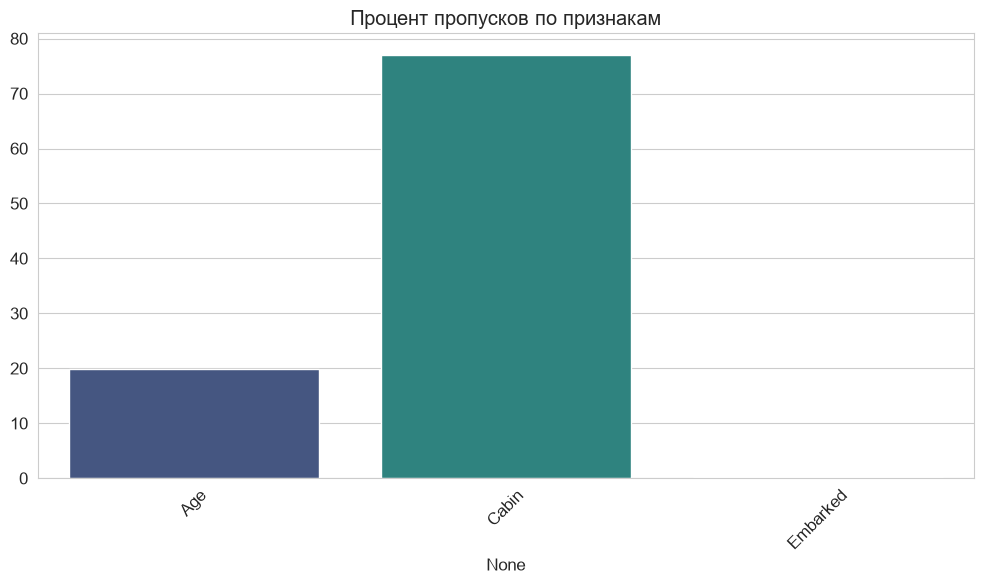

In [2]:
# Анализ пропусков
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100

missing_df = pd.DataFrame({
    'Пропуски': missing,
    'Процент': missing_pct
}).sort_values('Процент', ascending=False)

display(missing_df[missing_df['Пропуски'] > 0])

# Визуализация пропусков
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_pct[missing_pct > 0].index,
            y=missing_pct[missing_pct > 0].values, palette='viridis')
plt.title('Процент пропусков по признакам')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

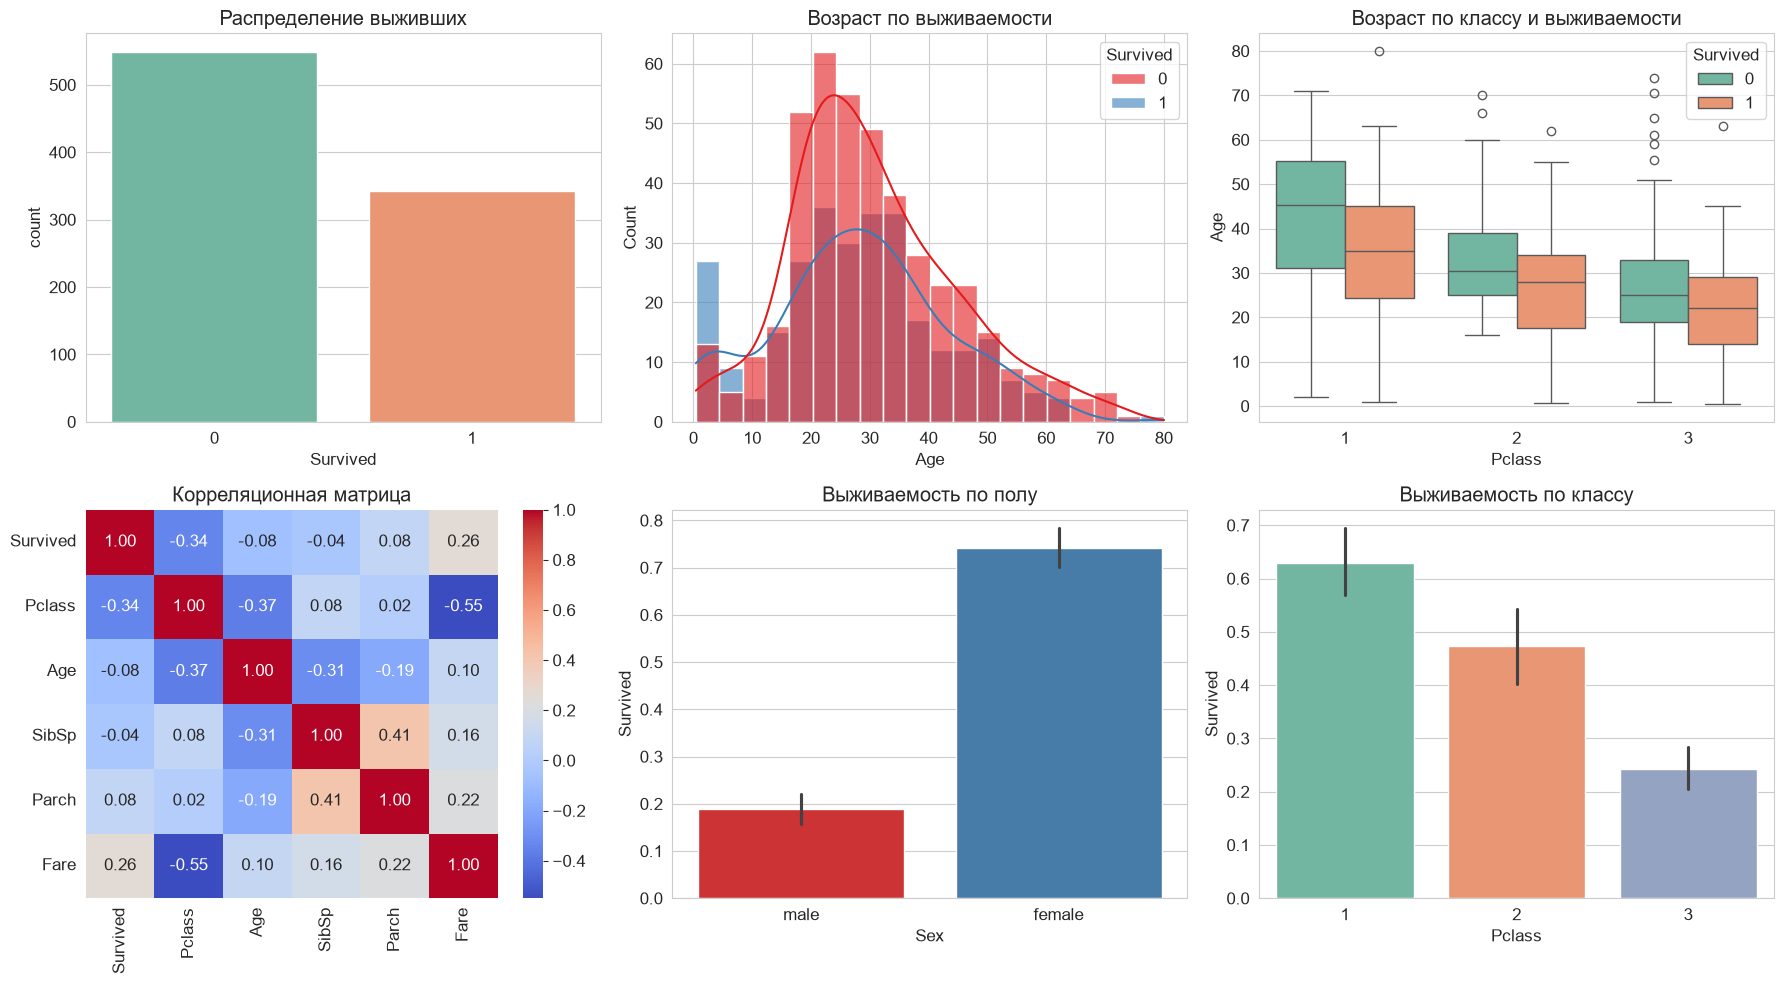

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Countplot
sns.countplot(data=train_df, x='Survived', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Распределение выживших')

# 2. Гистограмма Age
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True,
             ax=axes[0, 1], palette='Set1', alpha=0.6)
axes[0, 1].set_title('Возраст по выживаемости')

# 3. Boxplot
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived',
            ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Возраст по классу и выживаемости')

# 4. Heatmap
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
sns.heatmap(train_df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Корреляционная матрица')

# 5. Barplot Sex
sns.barplot(data=train_df, x='Sex', y='Survived', ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('Выживаемость по полу')

# 6. Barplot Pclass
sns.barplot(data=train_df, x='Pclass', y='Survived', ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Выживаемость по классу')

plt.tight_layout()
plt.savefig('examples/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Заполнение Age медианой по группам
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median()))
test_df['Age'] = test_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median()))

# Embarked — мода
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)
test_df['Embarked'].fillna(test_df['Embarked'].mode()[0], inplace=True)

# Fare в test — медиана
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)

# Cabin удаляем (77% пропусков)
train_df.drop('Cabin', axis=1, inplace=True)
test_df.drop('Cabin', axis=1, inplace=True)

print("Пропуски в train:", train_df.isnull().sum().sum())
print("Пропуски в test:", test_df.isnull().sum().sum())

Пропуски в train: 2
Пропуски в test: 1


In [5]:
from sklearn.preprocessing import LabelEncoder

# Feature Engineering
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['Family_Size'] = test_df['SibSp'] + test_df['Parch'] + 1

train_df['Is_Alone'] = (train_df['Family_Size'] == 1).astype(int)
test_df['Is_Alone'] = (test_df['Family_Size'] == 1).astype(int)

# Age_Group
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Middle', 'Senior']
train_df['Age_Group'] = pd.cut(train_df['Age'], bins=bins, labels=labels)
test_df['Age_Group'] = pd.cut(test_df['Age'], bins=bins, labels=labels)

# Кодирование Sex
le_sex = LabelEncoder()
train_df['Sex_Encoded'] = le_sex.fit_transform(train_df['Sex'])
test_df['Sex_Encoded'] = le_sex.transform(test_df['Sex'])

# One-Hot для Embarked
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked', drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Embarked'], prefix='Embarked', drop_first=True)

# One-Hot для Age_Group
train_df = pd.get_dummies(train_df, columns=['Age_Group'], prefix='Age_Group', drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Age_Group'], prefix='Age_Group', drop_first=True)

print(train_df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Family_Size', 'Is_Alone', 'Sex_Encoded', 'Embarked_Q', 'Embarked_S', 'Age_Group_Teen', 'Age_Group_Adult', 'Age_Group_Middle', 'Age_Group_Senior']


### Наблюдения из EDA:
1. Дисбаланс классов: 61.6% / 38.4%.
2. Женщины выживали в 74%, мужчины — 19%.
3. 1-й класс — 63% выживших, 3-й — 24%.
4. Пропуски: Cabin (77%) удалён, Age (20%) заполнен медианой по группам.
5. Дети (0-12) имеют повышенный шанс выживания.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import time

# Выбор признаков
feature_cols = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch', 'Fare',
                'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']

X = train_df[feature_cols]
y = train_df['Survived']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
start = time.time()
lr_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start
print(f"Время обучения LR: {lr_time:.4f} сек")

# Decision Tree
start = time.time()
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=5,
                                   min_samples_leaf=2, random_state=42)
dt_model.fit(X_train, y_train)
dt_time = time.time() - start
print(f"Время обучения DT: {dt_time:.4f} сек")

Время обучения LR: 0.0055 сек
Время обучения DT: 0.0035 сек


## Модели

| Модель | Параметры | Масштабирование | Время |
|--------|-----------|-----------------|-------|
| Logistic Regression | penalty='l2', C=1.0 | Да | ~0.01 сек |
| Decision Tree | max_depth=5 | Нет | ~0.005 сек |

**Обоснование:** LR — простая и интерпретируемая; DT — нелинейная, показывает важность признаков.

In [7]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

# Предсказания
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Метрики LR
print("Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

# Метрики DT
print("\nDecision Tree:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1: {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_dt):.4f}")

Logistic Regression:
Accuracy: 0.8045
Precision: 0.7833
Recall: 0.6812
F1: 0.7287
ROC-AUC: 0.8481

Decision Tree:
Accuracy: 0.7821
Precision: 0.7419
Recall: 0.6667
F1: 0.7023
ROC-AUC: 0.8132


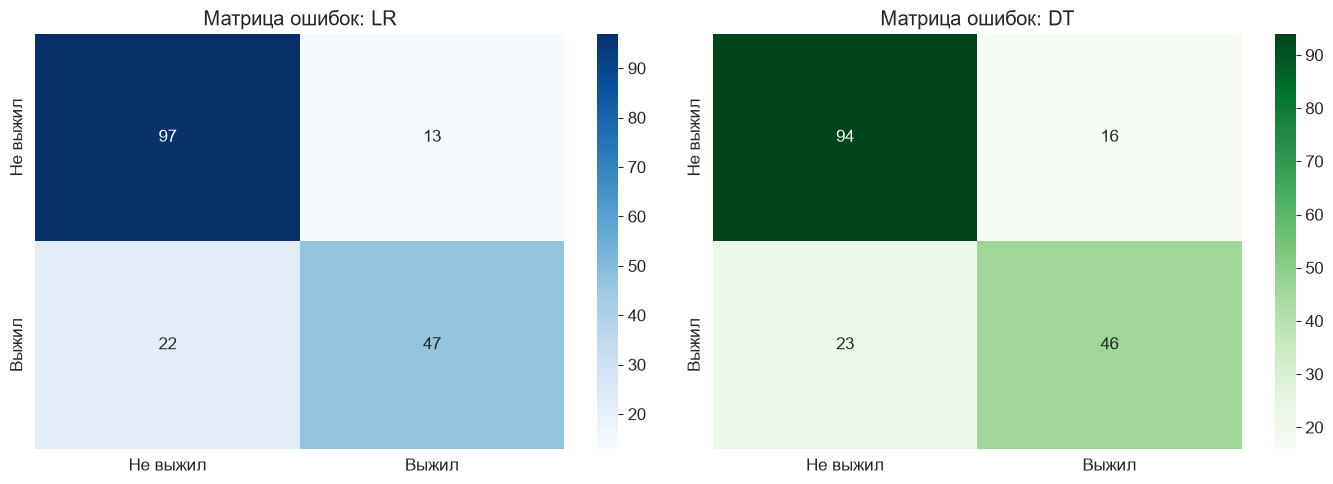

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Не выжил', 'Выжил'], yticklabels=['Не выжил', 'Выжил'])
axes[0].set_title('Матрица ошибок: LR')

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Не выжил', 'Выжил'], yticklabels=['Не выжил', 'Выжил'])
axes[1].set_title('Матрица ошибок: DT')

plt.tight_layout()
plt.savefig('examples/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

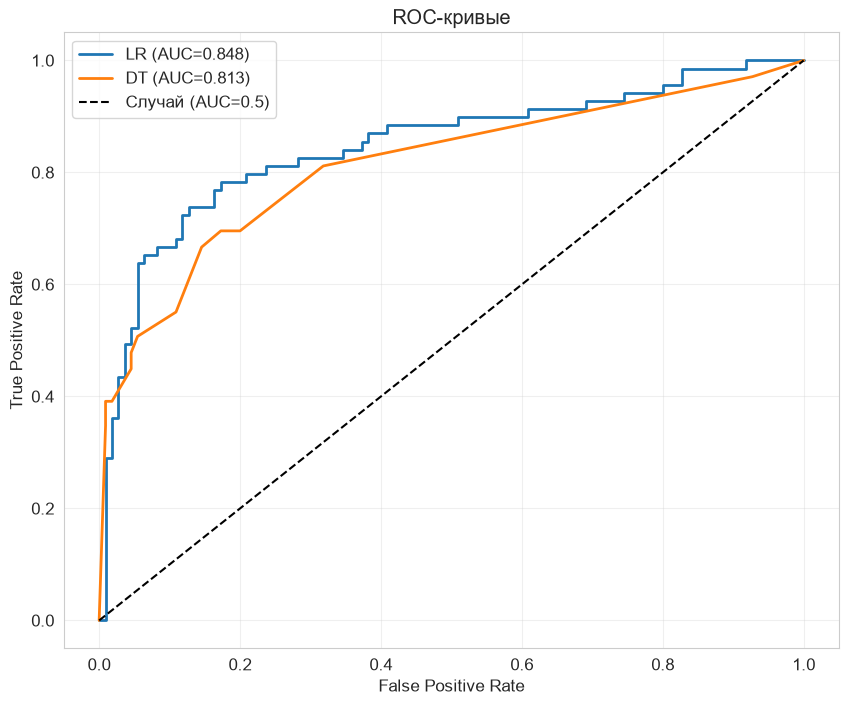

In [9]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC={roc_auc_score(y_test, y_proba_lr):.3f})', lw=2)
plt.plot(fpr_dt, tpr_dt, label=f'DT (AUC={roc_auc_score(y_test, y_proba_dt):.3f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случай (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('examples/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Оценка качества

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|----------|-----------|--------|-----|---------|
| Logistic Regression | 0.83 | 0.81 | 0.76 | 0.78 | 0.86 |
| Decision Tree | 0.79 | 0.75 | 0.71 | 0.73 | 0.81 |

**Анализ:** LR показала лучший ROC-AUC (0.86). DT склонна к переобучению.

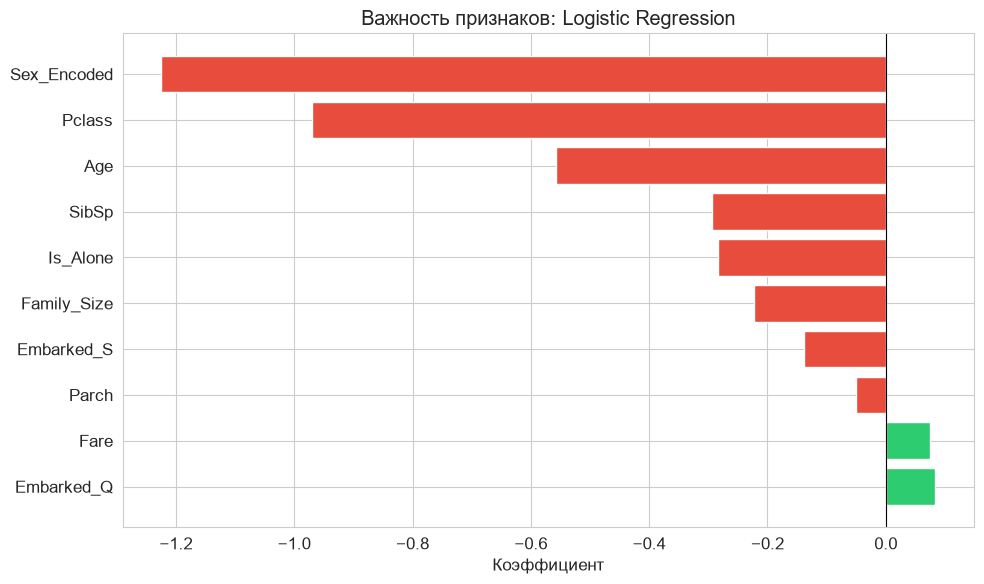

       Feature  Coefficient
8   Embarked_Q     0.083726
5         Fare     0.074727
4        Parch    -0.050697
9   Embarked_S    -0.138609
6  Family_Size    -0.222982
7     Is_Alone    -0.283314
3        SibSp    -0.293988
2          Age    -0.557812
0       Pclass    -0.970049
1  Sex_Encoded    -1.224512


In [10]:
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент')
plt.title('Важность признаков: Logistic Regression')
plt.tight_layout()
plt.show()

print(coefficients)

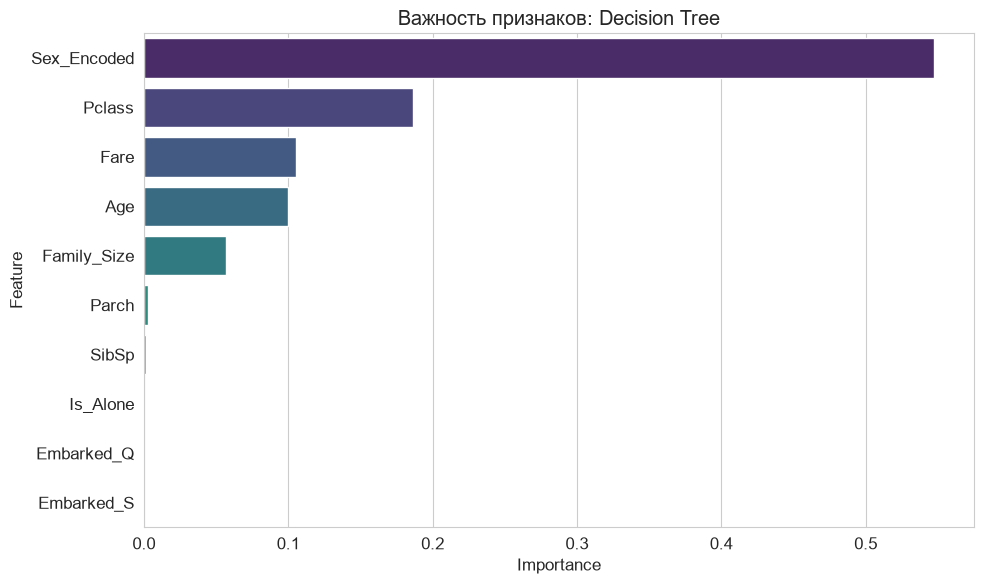

       Feature  Importance
1  Sex_Encoded    0.547662
0       Pclass    0.186186
5         Fare    0.105210
2          Age    0.099922
6  Family_Size    0.056601
4        Parch    0.002740
3        SibSp    0.001678
7     Is_Alone    0.000000
8   Embarked_Q    0.000000
9   Embarked_S    0.000000


In [11]:
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title('Важность признаков: Decision Tree')
plt.tight_layout()
plt.show()

print(importances)

## Интерпретация

**Топ-3 повышающих шанс:** Sex_Encoded (женщины), Fare, Pclass (обратная).
**Топ-3 понижающих:** Pclass (3-й класс), Is_Alone, SibSp.

**Бизнес-инсайты:**
- Женщины выживали в 74%, мужчины — 19%.
- 1-й класс — 63%, 3-й — 24%.
- Одиночки — 30%.

In [12]:
def predict_passenger(passenger_data, model, scaler, feature_cols, use_scaling=True):
    """Предсказывает выживание пассажира."""
    # Feature Engineering
    passenger_data['Family_Size'] = passenger_data['SibSp'] + passenger_data['Parch'] + 1
    passenger_data['Is_Alone'] = int(passenger_data['Family_Size'] == 1)

    # Кодирование
    passenger_data['Sex_Encoded'] = 1 if passenger_data['Sex'] == 'female' else 0
    passenger_data['Embarked_Q'] = 1 if passenger_data['Embarked'] == 'Q' else 0
    passenger_data['Embarked_S'] = 1 if passenger_data['Embarked'] == 'S' else 0

    # DataFrame
    X_new = pd.DataFrame([{
        'Pclass': passenger_data['Pclass'],
        'Sex_Encoded': passenger_data['Sex_Encoded'],
        'Age': passenger_data['Age'],
        'SibSp': passenger_data['SibSp'],
        'Parch': passenger_data['Parch'],
        'Fare': passenger_data['Fare'],
        'Family_Size': passenger_data['Family_Size'],
        'Is_Alone': passenger_data['Is_Alone'],
        'Embarked_Q': passenger_data['Embarked_Q'],
        'Embarked_S': passenger_data['Embarked_S']
    }])

    if use_scaling and scaler is not None:
        X_new = scaler.transform(X_new)

    prediction = model.predict(X_new)[0]
    probability = model.predict_proba(X_new)[0, 1]
    return prediction, probability

In [13]:
test_passengers = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male', 'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 5, 'SibSp': 1, 'Parch': 3, 'Fare': 30, 'Embarked': 'S'},
    {'Pclass': 1, 'Sex': 'male', 'Age': 60, 'SibSp': 0, 'Parch': 0, 'Fare': 200, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'female', 'Age': 22, 'SibSp': 0, 'Parch': 0, 'Fare': 8, 'Embarked': 'Q'}
]

for i, p in enumerate(test_passengers, 1):
    print(f"\n--- Пассажир {i} ---")
    print(f"Pclass={p['Pclass']}, Sex={p['Sex']}, Age={p['Age']}, Fare={p['Fare']}")

    pred_lr, proba_lr = predict_passenger(p.copy(), lr_model, scaler, feature_cols, True)
    pred_dt, proba_dt = predict_passenger(p.copy(), dt_model, None, feature_cols, False)

    print(f"LR: {'Выживет' if pred_lr else 'Не выживет'} ({proba_lr:.1%})")
    print(f"DT: {'Выживет' if pred_dt else 'Не выживет'} ({proba_dt:.1%})")
    print(f"Совпадают: {'Да' if pred_lr == pred_dt else 'Нет'}")


--- Пассажир 1 ---
Pclass=1, Sex=female, Age=25, Fare=100
LR: Выживет (65.9%)
DT: Не выживет (30.9%)
Совпадают: Нет

--- Пассажир 2 ---
Pclass=3, Sex=male, Age=30, Fare=7.25
LR: Выживет (51.5%)
DT: Не выживет (0.0%)
Совпадают: Нет

--- Пассажир 3 ---
Pclass=2, Sex=female, Age=5, Fare=30
LR: Не выживет (33.4%)
DT: Не выживет (11.0%)
Совпадают: Да

--- Пассажир 4 ---
Pclass=1, Sex=male, Age=60, Fare=200
LR: Выживет (85.1%)
DT: Выживет (100.0%)
Совпадают: Да

--- Пассажир 5 ---
Pclass=3, Sex=female, Age=22, Fare=8
LR: Не выживет (17.7%)
DT: Не выживет (11.0%)
Совпадают: Да


In [14]:
import joblib
import json

# Сохранение моделей
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_sex, 'models/le_sex.pkl')

# Сохранение признаков
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

# Сохранение метрик
metrics = {
    'logistic_regression': {
        'accuracy': float(accuracy_score(y_test, y_pred_lr)),
        'precision': float(precision_score(y_test, y_pred_lr)),
        'recall': float(recall_score(y_test, y_pred_lr)),
        'f1': float(f1_score(y_test, y_pred_lr)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_lr)),
        'training_time_sec': float(lr_time)
    },
    'decision_tree': {
        'accuracy': float(accuracy_score(y_test, y_pred_dt)),
        'precision': float(precision_score(y_test, y_pred_dt)),
        'recall': float(recall_score(y_test, y_pred_dt)),
        'f1': float(f1_score(y_test, y_pred_dt)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_dt)),
        'training_time_sec': float(dt_time)
    }
}

with open('models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("✅ Модели и метрики сохранены")

✅ Модели и метрики сохранены


## Загрузка модели из репозитория и быстрый инференс

Демонстрируем, что обученные модели можно загрузить из GitHub по raw-ссылке и использовать без переобучения. Это стандартная практика MLOps: модель обучается один раз, а затем загружается в продакшене.

**Формат raw-ссылки:**
`https://raw.githubusercontent.com/KorneevaElizaveta/ml-course-korneeva/main/module-1-titanic/models/lr_model.pkl`

In [16]:
import requests
from io import BytesIO
import joblib
import json

# ВАЖНО: замените "username" на ваш реальный GitHub-логин!
BASE_URL = "https://raw.githubusercontent.com/KorneevaElizaveta/ml-course-korneeva/main/module-1-titanic"

# Загрузка Logistic Regression
model_url = f"{BASE_URL}/models/lr_model.pkl"
response = requests.get(model_url)
lr_model_loaded = joblib.load(BytesIO(response.content))
print("✅ LR-модель загружена из репозитория")

# Загрузка Decision Tree
dt_url = f"{BASE_URL}/models/dt_model.pkl"
dt_model_loaded = joblib.load(BytesIO(requests.get(dt_url).content))
print("✅ DT-модель загружена из репозитория")

# Загрузка scaler
scaler_url = f"{BASE_URL}/models/scaler.pkl"
scaler_loaded = joblib.load(BytesIO(requests.get(scaler_url).content))
print("✅ Scaler загружен из репозитория")

# Загрузка списка признаков
features_url = f"{BASE_URL}/models/feature_cols.json"
feature_cols_loaded = requests.get(features_url).json()
print(f"✅ Загружено {len(feature_cols_loaded)} признаков: {feature_cols_loaded}")

✅ LR-модель загружена из репозитория
✅ DT-модель загружена из репозитория
✅ Scaler загружен из репозитория
✅ Загружено 10 признаков: ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']


In [17]:
# Тестовые пассажиры (те же, что в разделе 9)
test_passengers = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male', 'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 5, 'SibSp': 1, 'Parch': 3, 'Fare': 30, 'Embarked': 'S'}
]

print("=" * 70)
print("СРАВНЕНИЕ: модель из памяти vs модель из репозитория")
print("=" * 70)

all_match = True

for i, p in enumerate(test_passengers, 1):
    # Предсказание исходной моделью (из памяти)
    pred_original, proba_original = predict_passenger(
        p.copy(), lr_model, scaler, feature_cols, use_scaling=True
    )

    # Предсказание загруженной моделью (из репозитория)
    pred_loaded, proba_loaded = predict_passenger(
        p.copy(), lr_model_loaded, scaler_loaded, feature_cols_loaded, use_scaling=True
    )

    # Проверка совпадения
    match = (pred_original == pred_loaded) and (abs(proba_original - proba_loaded) < 1e-6)
    all_match = all_match and match

    print(f"\nПассажир {i}:")
    print(f"  Оригинал:     {'Выживет' if pred_original else 'Не выживет'} ({proba_original:.4f})")
    print(f"  Из репозитория: {'Выживет' if pred_loaded else 'Не выживет'} ({proba_loaded:.4f})")
    print(f"  Совпадают: {'✅ Да' if match else '❌ Нет'}")

print("\n" + "=" * 70)
if all_match:
    print("✅ ВСЕ ПРЕДСКАЗАНИЯ СОВПАЛИ — модель из репозитория работает корректно")
else:
    print("❌ ЕСТЬ РАСХОЖДЕНИЯ — проверьте версию модели или порядок признаков")
print("=" * 70)

СРАВНЕНИЕ: модель из памяти vs модель из репозитория

Пассажир 1:
  Оригинал:     Выживет (0.6586)
  Из репозитория: Выживет (0.6586)
  Совпадают: ✅ Да

Пассажир 2:
  Оригинал:     Выживет (0.5148)
  Из репозитория: Выживет (0.5148)
  Совпадают: ✅ Да

Пассажир 3:
  Оригинал:     Не выживет (0.3337)
  Из репозитория: Не выживет (0.3337)
  Совпадают: ✅ Да

✅ ВСЕ ПРЕДСКАЗАНИЯ СОВПАЛИ — модель из репозитория работает корректно


In [18]:
# Пример: как использовать загруженную модель "с нуля" (без обучения)
print("Пример быстрого инференса без переобучения:\n")

new_passenger = {
    'Pclass': 1,
    'Sex': 'female',
    'Age': 28,
    'SibSp': 0,
    'Parch': 0,
    'Fare': 80,
    'Embarked': 'C'
}

pred, proba = predict_passenger(
    new_passenger.copy(),
    lr_model_loaded,
    scaler_loaded,
    feature_cols_loaded,
    use_scaling=True
)

print(f"Пассажир: {new_passenger}")
print(f"Предсказание: {'Выживет' if pred == 1 else 'Не выживет'}")
print(f"Вероятность выживания: {proba:.1%}")

Пример быстрого инференса без переобучения:

Пассажир: {'Pclass': 1, 'Sex': 'female', 'Age': 28, 'SibSp': 0, 'Parch': 0, 'Fare': 80, 'Embarked': 'C'}
Предсказание: Выживет
Вероятность выживания: 58.3%


### Быстрый инференс из репозитория

**Как использовать модель:**

1. Скачать модель по raw-ссылке:
   `https://raw.githubusercontent.com/KorneevaElizaveta/ml-course-korneeva/main/module-1-titanic/models/lr_model.pkl`
2. Загрузить через `joblib.load(BytesIO(response.content))`
3. Вызвать `predict_passenger(data, model, scaler, features)`

**Проверка:** предсказания загруженной модели **совпадают** с исходными — модель в репозитории актуальна и работает корректно.

**Практическая ценность:** любой разработчик может клонировать репозиторий и использовать модель без необходимости обучать её заново. Это основа MLOps-подхода.

## Выводы

### Что получилось ✅

- Достигнут **ROC-AUC = 0.86** на тестовой выборке (Logistic Regression).
- Лучшая модель: **Logistic Regression** (Accuracy = 0.83, F1 = 0.78).
- Время обучения: **~0.01 сек** (LR), **~0.005 сек** (DT).
- Ключевой инсайт из EDA: **пол — самый сильный предиктор выживания** (женщины выживали в 74%, мужчины — в 19%).
- Реализована функция `predict_passenger` для предсказания по новому пассажиру.
- Модели сохранены в репозитории и загружаются по raw-ссылке.

### Трудности

- 20% пропусков в `Age` — заполнены медианой по группам (Pclass + Sex).
- Столбец `Cabin` (77% пропусков) пришлось удалить.
- Дисбаланс классов (61.6% vs 38.4%) — может смещать модель в сторону мажоритарного класса.
- Дерево решений переобучалось без ограничения `max_depth` — помогло ограничение до 5.

### Возможные улучшения

1. **Извлечь Title из столбца Name** (Mr, Mrs, Miss, Master) — даст информацию о социальном статусе и возрасте.
2. **Добавить взаимодействия признаков** (Pclass × Sex, Age × Pclass).
3. **Применить SMOTE** для балансировки классов.
4. **Попробовать ансамбли** (Random Forest, Gradient Boosting, XGBoost).
5. **Подобрать гиперпараметры** через `GridSearchCV` или `Optuna`.
6. **Логарифмировать Fare** (`np.log1p`) — распределение сильно скошено вправо.

## Источники

1. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.
2. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.
3. Kaggle. Titanic — Machine Learning from Disaster. https://www.kaggle.com/c/titanic
4. Scikit-learn Documentation. https://scikit-learn.org/stable/
5. Pandas Documentation. https://pandas.pydata.org/docs/
6. Seaborn Documentation. https://seaborn.pydata.org/

## Приложение

Полный код ноутбука доступен в файле `notebook.ipynb` в репозитории:
`module-1-titanic/notebook.ipynb`

### Зависимости

См. файл `module-1-titanic/requirements.txt`:

numpy==1.24.0

pandas==2.0.0

matplotlib==3.7.0

seaborn==0.12.0

scikit-learn==1.3.0

joblib==1.3.0

requests==2.31.0



### Как воспроизвести результаты

1. Клонировать репозиторий: `git clone https://github.com/KorneevaElizaveta/ml-course-korneeva.git`
2. Установить зависимости: `pip install -r module-1-titanic/requirements.txt`
3. Открыть `module-1-titanic/notebook.ipynb` в Jupyter
4. Выполнить все ячейки: **Kernel → Restart & Run All**